### LAB_01

Original Data:     [0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0]
Demodulated Data:  [0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0]


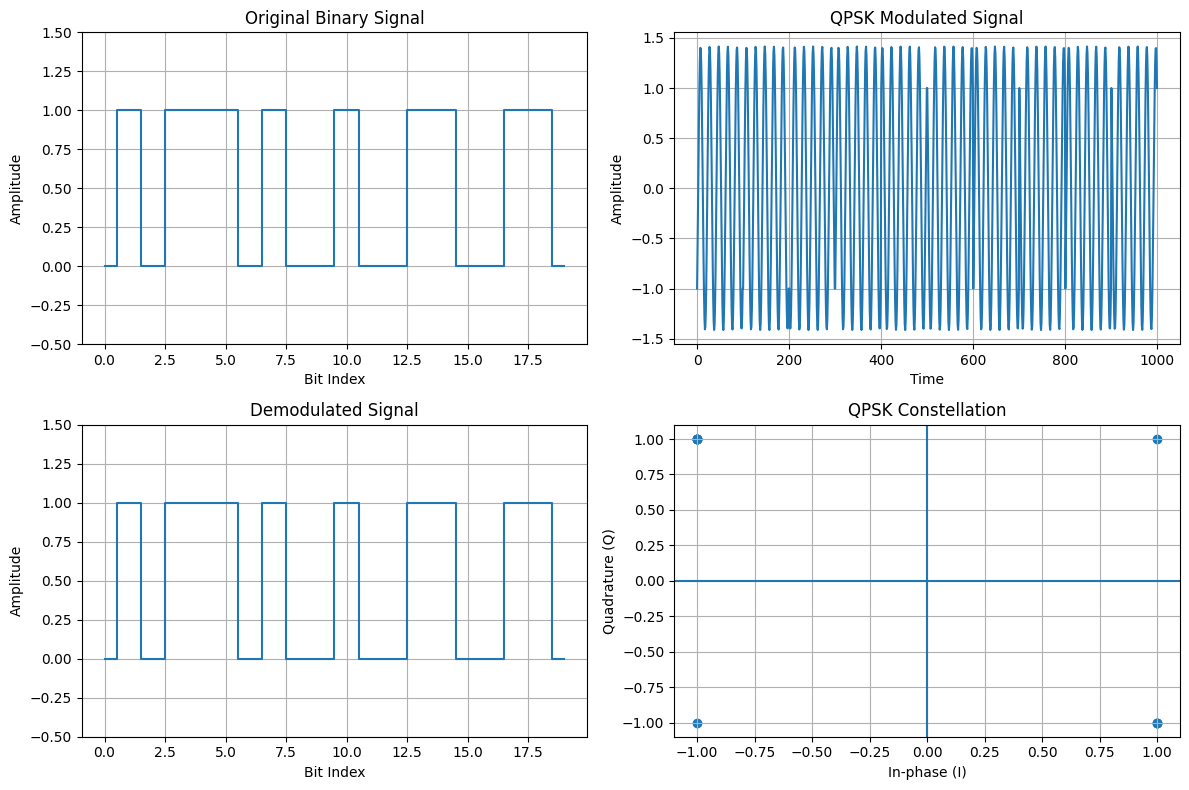

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Original binary data
data = np.random.randint(0, 2, 20)
pairs = data.reshape(-1, 2)

# QPSK mapping
map_dict = {(0,0):(1,1), (0,1):(-1,1), (1,1):(-1,-1), (1,0):(1,-1)}
symbols = np.array([map_dict[tuple(p)] for p in pairs])

I, Q = symbols[:,0], symbols[:,1]

# Carrier & modulation
t = np.linspace(0, 1, 100)
fc = 5
signal = np.concatenate([
    I[i]*np.cos(2*np.pi*fc*t) + Q[i]*np.sin(2*np.pi*fc*t)
    for i in range(len(I))
])

# Demodulation
demod = []
for i,q in zip(I,Q):
    if i>0 and q>0: demod += [0,0]
    elif i<0 and q>0: demod += [0,1]
    elif i<0 and q<0: demod += [1,1]
    else: demod += [1,0]

demod = np.array(demod)

# --------- COMBINED PLOTS ---------
plt.figure(figsize=(12,8))

# 1. Original Signal
plt.subplot(2,2,1)
plt.step(range(len(data)), data, where='mid')
plt.title("Original Binary Signal")
plt.xlabel("Bit Index")
plt.ylabel("Amplitude")
plt.ylim(-0.5, 1.5)
plt.grid()

# 2. Modulated Signal
plt.subplot(2,2,2)
plt.plot(signal)
plt.title("QPSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 3. Demodulated Signal
plt.subplot(2,2,3)
plt.step(range(len(demod)), demod, where='mid')
plt.title("Demodulated Signal")
plt.xlabel("Bit Index")
plt.ylabel("Amplitude")
plt.ylim(-0.5, 1.5)
plt.grid()

# 4. Constellation Diagram
plt.subplot(2,2,4)
plt.scatter(I, Q)
plt.title("QPSK Constellation")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axhline(0)
plt.axvline(0)
plt.grid()

# Adjust layout
plt.tight_layout()

# Print comparison
print("Original Data:    ", data)
print("Demodulated Data: ", demod)

plt.show()

## LAB_02

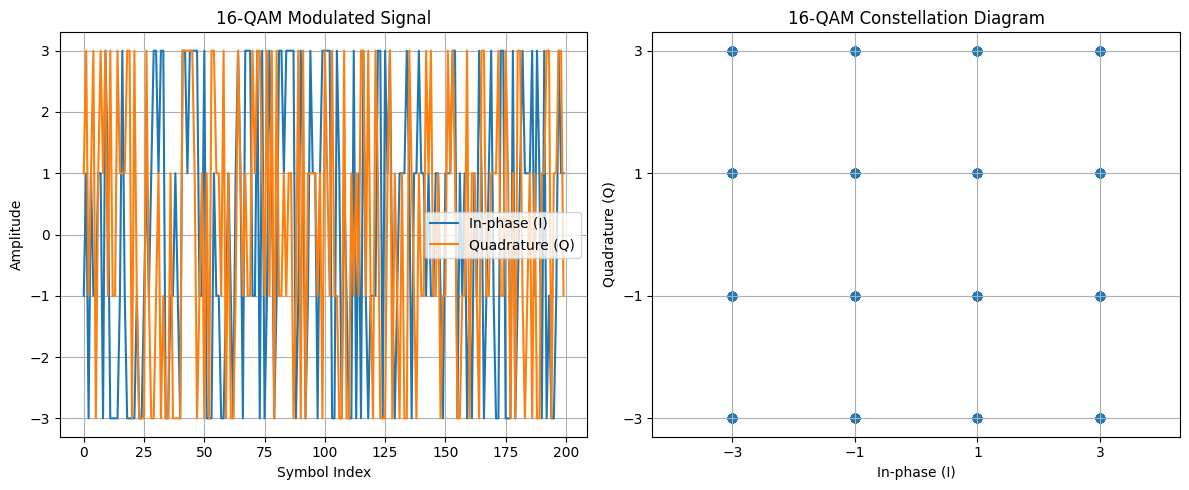

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Number of symbols
N = 200

# Generate random bits
bits = np.random.randint(0, 2, N*4)

# Group into 4 bits
bit_groups = bits.reshape((N, 4))

# Gray coding mapping
mapping = {
    (0,0): -3,
    (0,1): -1,
    (1,1):  1,
    (1,0):  3
}

# Generate I and Q components
I = np.array([mapping[tuple(b[:2])] for b in bit_groups])
Q = np.array([mapping[tuple(b[2:])] for b in bit_groups])

# QAM Signal
qam_signal = I + 1j * Q

# Time axis
t = np.arange(N)

# ----------- COMBINED PLOT -------------
plt.figure(figsize=(12,5))

# 1. Modulated Signal
plt.subplot(1,2,1)
plt.plot(t, np.real(qam_signal), label='In-phase (I)')
plt.plot(t, np.imag(qam_signal), label='Quadrature (Q)')
plt.title("16-QAM Modulated Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

# 2. Constellation Diagram
plt.subplot(1,2,2)
plt.scatter(np.real(qam_signal), np.imag(qam_signal))
plt.title("16-QAM Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])
plt.grid()
plt.axis('equal')

# Adjust layout
plt.tight_layout()

plt.show()

## LAB_03

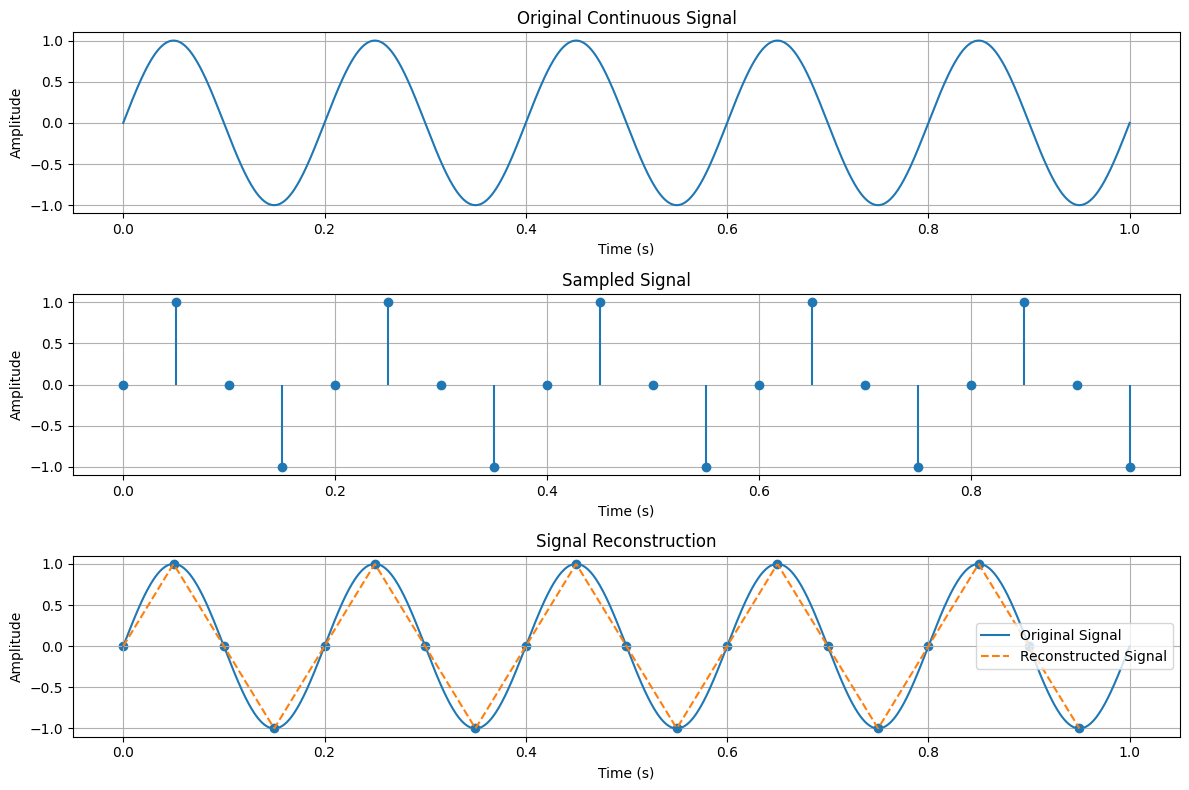

## LAB_04


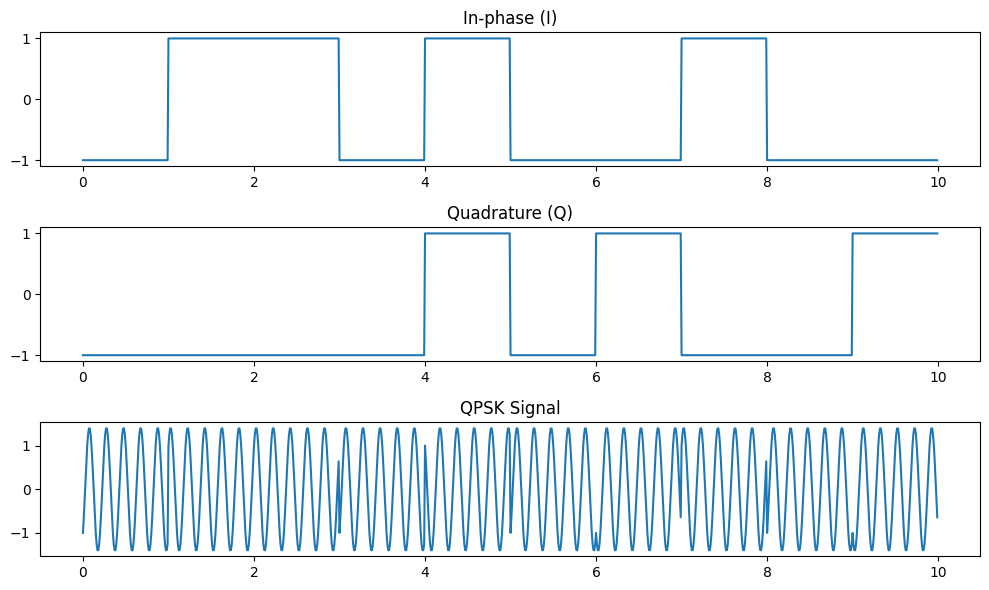

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_bits = 20;fc = 5;samples_per_bit = 100

# Step 1: Generate bits
bits = np.random.randint(0, 2, num_bits)

# Step 2: Group into pairs
bit_pairs = bits.reshape(-1, 2)

# Step 3: QPSK Mapping (Gray coding)
mapping = {
    (0,0):(1,1), (0,1):(-1,1),
    (1,1):(-1,-1), (1,0):(1,-1)
}

# Generate I and Q signals
I, Q = [], []
for pair in bit_pairs:
    i, q = mapping[tuple(pair)]
    I += [i]*samples_per_bit
    Q += [q]*samples_per_bit

I, Q = np.array(I), np.array(Q)

# Step 4: Time axis
t = np.arange(len(I)) / samples_per_bit

# Step 5: Carrier signals
carrier_I = np.cos(2*np.pi*fc*t)
carrier_Q = np.sin(2*np.pi*fc*t)

# Step 6: QPSK Modulation
qpsk_signal = I*carrier_I - Q*carrier_Q

# --------- Plot ---------
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t, I)
plt.title("In-phase (I)")

plt.subplot(3,1,2)
plt.plot(t, Q)
plt.title("Quadrature (Q)")

plt.subplot(3,1,3)
plt.plot(t, qpsk_signal)
plt.title("QPSK Signal")

plt.tight_layout()
plt.show()

## LAB_05

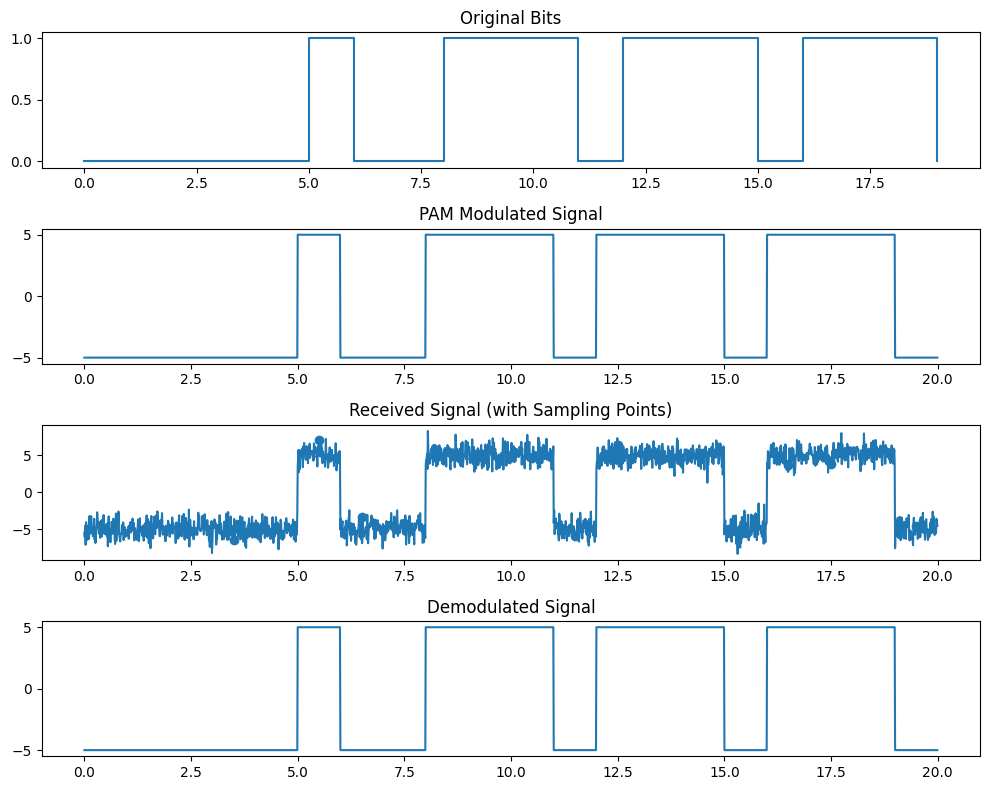

Original bits:   [0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0]
Recovered bits:  [0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0]


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_bits = 20
samples_per_bit = 100
A = 5   # Amplitude

# Step 1: Generate random bits
bits = np.random.randint(0, 2, num_bits)

# Step 2: PAM Mapping (0 → -A, 1 → +A)
symbols = np.where(bits == 1, A, -A)

# Step 3: Modulation (Upsampling)
pam_signal = np.repeat(symbols, samples_per_bit)

# Time axis
t = np.arange(len(pam_signal)) / samples_per_bit

# Step 4: Add noise (channel)
noise = np.random.normal(0, 1, len(pam_signal))
received_signal = pam_signal + noise

# ------------------------
# Step 5: Demodulation
# ------------------------

# Sampling at middle of each bit
sample_idx = np.arange(samples_per_bit//2, len(received_signal), samples_per_bit)
samples = received_signal[sample_idx]

# Decision rule (threshold = 0)
recovered_bits = (samples > 0).astype(int)

# Reconstruct signal (for visualization)
demod_symbols = np.where(recovered_bits == 1, A, -A)
demod_signal = np.repeat(demod_symbols, samples_per_bit)

# ------------------------
# Step 6: Plotting
# ------------------------
plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.step(range(len(bits)), bits, where='post')
plt.title("Original Bits")

plt.subplot(4,1,2)
plt.plot(t, pam_signal)
plt.title("PAM Modulated Signal")

plt.subplot(4,1,3)
plt.plot(t, received_signal)
plt.scatter(sample_idx/samples_per_bit, samples)
plt.title("Received Signal (with Sampling Points)")

plt.subplot(4,1,4)
plt.plot(t, demod_signal)
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

# Results
print("Original bits:  ", bits)
print("Recovered bits: ", recovered_bits)

## LAB_06

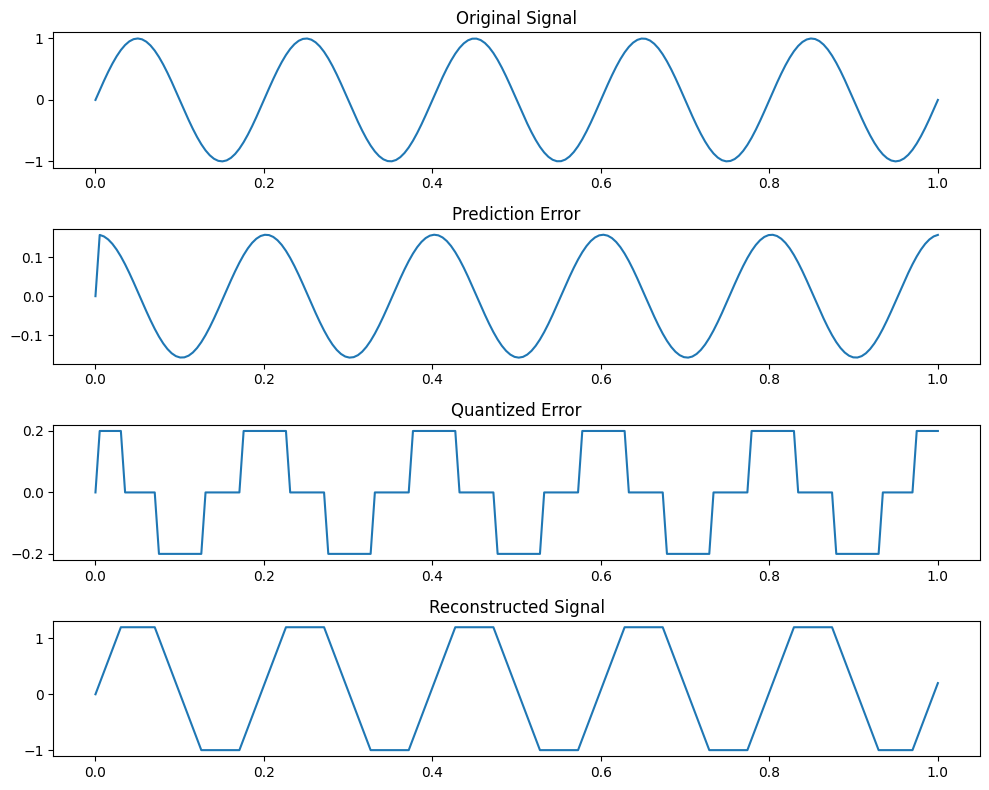

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate input signal
t = np.linspace(0, 1, 200)
x = np.sin(2 * np.pi * 5 * t)

# Step 2: DPCM Modulation
step_size = 0.2

predicted = np.zeros_like(x)
error = np.zeros_like(x)
q_error = np.zeros_like(x)

for i in range(1, len(x)):
    predicted[i] = x[i-1]                # Predictor
    error[i] = x[i] - predicted[i]       # Difference
    q_error[i] = step_size * np.round(error[i] / step_size)  # Quantization

# Step 3: DPCM Demodulation
reconstructed = np.zeros_like(x)

for i in range(1, len(x)):
    reconstructed[i] = reconstructed[i-1] + q_error[i]

# ------------------------
# Step 4: Plotting
# ------------------------
plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(t, x)
plt.title("Original Signal")

plt.subplot(4,1,2)
plt.plot(t, error)
plt.title("Prediction Error")

plt.subplot(4,1,3)
plt.plot(t, q_error)
plt.title("Quantized Error")

plt.subplot(4,1,4)
plt.plot(t, reconstructed)
plt.title("Reconstructed Signal")

plt.tight_layout()
plt.show()